# 📢 Semana 4: Auditoría de Campañas de Marketing (Conversión)

En este bloque, analizamos el modelo de **Propensión de Compra**. La IA ha clasificado a los clientes en "Compradores" y "No Compradores". Nuestro objetivo con **SHAP** es identificar los puntos de fricción.

### 🧠 Estrategia de Marketing:
1. **Factores de Abandono:** ¿Es el precio? ¿Es la falta de interacción previa?
2. **Perfil VIP:** ¿Qué características definen a nuestro cliente más fiel?
3. **Acción Comercial:** Usaremos la interpretación para decidir si enviamos un cupón de descuento o una newsletter informativa.

✅ Analizando 5 clientes de marketing.


<Figure size 1000x600 with 0 Axes>

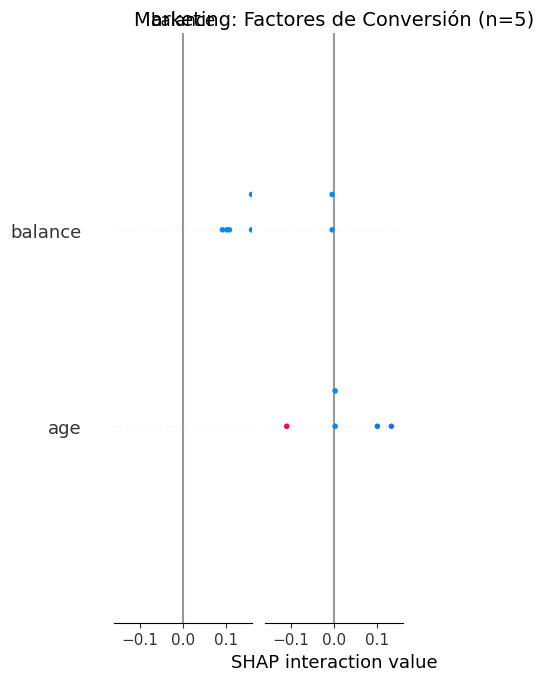

In [2]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. CARGA DE RECURSOS
modelo_mkt = joblib.load('../../../models/modelo_marketing_optimizado_v2.pkl')
df_mkt = pd.read_csv('../../../data/processed/marketing_limpio.csv')

# 2. ALINEACIÓN Y MUESTREO DINÁMICO
cols = modelo_mkt.feature_names_in_
X_mkt_all = df_mkt.reindex(columns=cols, fill_value=0)

# [Especialista]: Si el dataset es pequeño, usamos todo. Si es grande, limitamos a 500.
n_muestras = min(len(X_mkt_all), 500)
X_mkt = X_mkt_all.sample(n=n_muestras, random_state=42)
print(f"✅ Analizando {n_muestras} clientes de marketing.")

# 3. INTERPRETACIÓN SHAP
explainer = shap.TreeExplainer(modelo_mkt)
shap_values = explainer.shap_values(X_mkt, check_additivity=False)

# 4. GRÁFICO
plt.figure(figsize=(10, 6))
v_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(v_plot, X_mkt, show=False)

plt.title(f"Marketing: Factores de Conversión (n={n_muestras})", fontsize=14)
plt.show()